# sarimax_rs vs statsmodels 비교 분석

ARIMA / ARIMAX / SARIMA / SARIMAX 모델을 두 패키지로 fitting한 뒤,
- 로그우도(log-likelihood) 유사도
- 수렴 속도(fitting time)
- 파라미터 일치도

를 비교합니다.

**데이터**
- 일단위: `peak_load.csv` (일별 최대전력, 2019~2024)
- 시간단위: `power_demand_2024.csv` (시간별 전력수요, 2024)

In [1]:
import numpy as np
import polars as pl
import time
import warnings
warnings.filterwarnings('ignore')

from sarimax_py.model import SARIMAXModel
from sarimax_py.auto import auto_arima

from statsmodels.tsa.statespace.sarimax import SARIMAX as SM_SARIMAX
import pmdarima as pm

## 1. 데이터 로드 및 전처리

In [2]:
# 일단위 데이터
df_daily = pl.read_csv("peak_load.csv")
print(f"일단위 데이터: {df_daily.shape}")
print(df_daily.head())

# 시간단위 데이터
df_hourly = pl.read_csv("power_demand_2024.csv")
print(f"\n시간단위 데이터: {df_hourly.shape}")
print(df_hourly.head())

일단위 데이터: (2131, 11)
shape: (5, 11)
┌────────────┬──────────┬───────────┬───────────┬───┬────────┬────────┬────────┬───────────────────┐
│ date       ┆ peakload ┆ daily_hm  ┆ daily_ta  ┆ … ┆ summer ┆ autoum ┆ winter ┆ is_holiday_dummie │
│ ---        ┆ ---      ┆ ---       ┆ ---       ┆   ┆ ---    ┆ ---    ┆ ---    ┆ s                 │
│ str        ┆ f64      ┆ f64       ┆ f64       ┆   ┆ i64    ┆ i64    ┆ i64    ┆ ---               │
│            ┆          ┆           ┆           ┆   ┆        ┆        ┆        ┆ i64               │
╞════════════╪══════════╪═══════════╪═══════════╪═══╪════════╪════════╪════════╪═══════════════════╡
│ 2019-01-01 ┆ 69633.0  ┆ 85.86411  ┆ 24.321115 ┆ … ┆ 1      ┆ 0      ┆ 0      ┆ 0                 │
│ 2019-01-02 ┆ 64512.0  ┆ 74.996065 ┆ 23.330916 ┆ … ┆ 0      ┆ 1      ┆ 0      ┆ 0                 │
│ 2019-01-03 ┆ 66540.0  ┆ 46.405754 ┆ -1.806002 ┆ … ┆ 0      ┆ 1      ┆ 0      ┆ 0                 │
│ 2019-01-04 ┆ 60954.0  ┆ 61.862735 ┆ 21.299606 ┆ … ┆ 0 

In [18]:
# 일단위: peakload (전체 사용)
y_daily = df_daily["peakload"].to_numpy().astype(np.float64)

# 일단위 exog: daily_hm (일평균 습도), daily_ta (일평균 기온)
exog_daily = df_daily.select(["daily_hm", "daily_ta"]).to_numpy().astype(np.float64)

# 시간단위: power demand (최근 720시간 = 30일, 적절한 크기로 축소)
df_hourly = df_hourly.tail(62*24)
y_hourly = df_hourly["power demand(MW)"][-len(df_hourly):].to_numpy().astype(np.float64)

# 시간단위 exog: hm (습도), ta (기온)
exog_hourly = df_hourly.select(["hm", "ta"]).to_numpy().astype(np.float64)

print(f"y_daily: n={len(y_daily)}, range=[{y_daily.min():.0f}, {y_daily.max():.0f}]")
print(f"exog_daily: shape={exog_daily.shape}, cols=[daily_hm, daily_ta]")
print(f"y_hourly: n={len(y_hourly)}, range=[{y_hourly.min():.0f}, {y_hourly.max():.0f}]")
print(f"exog_hourly: shape={exog_hourly.shape}, cols=[hm, ta]")

y_daily: n=2131, range=[48946, 97115]
exog_daily: shape=(2131, 2), cols=[daily_hm, daily_ta]
y_hourly: n=744, range=[44737, 72272]
exog_hourly: shape=(744, 2), cols=[hm, ta]


In [19]:
print(len(y_hourly))
print(len(exog_hourly))

744
744


## 2. 비교 유틸리티 함수

In [20]:
def compare_fixed_order(y, order, seasonal_order=(0,0,0,0), exog=None,
                        trend='n', label=""):
    """고정 차수 모델로 sarimax_rs vs statsmodels 비교."""
    results = {"label": label, "order": order, "seasonal_order": seasonal_order}
    
    # --- sarimax_rs ---
    t0 = time.perf_counter()
    model_rs = SARIMAXModel(y, order=order, seasonal_order=seasonal_order,
                            exog=exog, trend=trend)
    res_rs = model_rs.fit()
    t_rs = time.perf_counter() - t0
    
    results["rs_time"] = t_rs
    results["rs_llf"] = res_rs.llf
    results["rs_aic"] = res_rs.aic
    results["rs_bic"] = res_rs.bic
    results["rs_params"] = res_rs.params
    results["rs_converged"] = res_rs.converged
    results["rs_nobs"] = res_rs.nobs
    
    # --- statsmodels ---
    t0 = time.perf_counter()
    model_sm = SM_SARIMAX(y, order=order, seasonal_order=seasonal_order,
                          exog=exog, trend=trend,
                          enforce_stationarity=True,
                          enforce_invertibility=True)
    res_sm = model_sm.fit(disp=False)
    t_sm = time.perf_counter() - t0
    
    results["sm_time"] = t_sm
    results["sm_llf"] = res_sm.llf
    results["sm_aic"] = res_sm.aic
    results["sm_bic"] = res_sm.bic
    results["sm_params"] = res_sm.params[:-1]  # statsmodels는 끝에 sigma2 포함
    results["sm_converged"] = res_sm.mle_retvals.get("converged", None)
    results["sm_nobs"] = res_sm.nobs
    
    # --- 비교 지표 ---
    results["llf_diff"] = abs(res_rs.llf - res_sm.llf)
    results["aic_diff"] = abs(res_rs.aic - res_sm.aic)
    results["speedup"] = t_sm / t_rs if t_rs > 0 else float('inf')
    
    # 파라미터 비교 (길이 맞추기)
    p_rs = results["rs_params"]
    p_sm = results["sm_params"]
    min_len = min(len(p_rs), len(p_sm))
    if min_len > 0:
        results["max_param_diff"] = np.max(np.abs(p_rs[:min_len] - p_sm[:min_len]))
    else:
        results["max_param_diff"] = np.nan
    
    return results


def print_comparison(r):
    """비교 결과 출력."""
    print(f"\n{'='*70}")
    print(f"  {r['label']}")
    print(f"  Order: {r['order']}, Seasonal: {r['seasonal_order']}")
    print(f"{'='*70}")
    print(f"{'':>20} {'sarimax_rs':>15} {'statsmodels':>15} {'차이':>12}")
    print(f"{'-'*62}")
    print(f"{'Log-likelihood':>20} {r['rs_llf']:>15.3f} {r['sm_llf']:>15.3f} {r['llf_diff']:>12.4f}")
    print(f"{'AIC':>20} {r['rs_aic']:>15.3f} {r['sm_aic']:>15.3f} {r['aic_diff']:>12.4f}")
    print(f"{'BIC':>20} {r['rs_bic']:>15.3f} {r['sm_bic']:>15.3f} {'':>12}")
    print(f"{'Fitting time (s)':>20} {r['rs_time']:>15.4f} {r['sm_time']:>15.4f} {r['speedup']:>11.1f}x")
    print(f"{'Converged':>20} {str(r['rs_converged']):>15} {str(r['sm_converged']):>15}")
    print(f"{'Max |Δparam|':>20} {r['max_param_diff']:>15.6f}")
    print()
    print(f"  rs params:  {np.array2string(r['rs_params'], precision=4, suppress_small=True)}")
    print(f"  sm params:  {np.array2string(r['sm_params'], precision=4, suppress_small=True)}")

---
## 3. ARIMA 비교 (비계절, 외생변수 없음)

일단위 peak load 데이터를 사용합니다.

In [21]:
arima_cases = [
    {"order": (1,1,1), "label": "ARIMA(1,1,1)"},
    {"order": (2,1,1), "label": "ARIMA(2,1,1)"},
    {"order": (3,1,2), "label": "ARIMA(3,1,2)"},
]

arima_results = []
for case in arima_cases:
    r = compare_fixed_order(y_daily, order=case["order"], trend='c',
                            label=case["label"])
    arima_results.append(r)
    print_comparison(r)


  ARIMA(1,1,1)
  Order: (1, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22414.246      -22430.299      16.0532
                 AIC       44836.492       44868.598      32.1063
                 BIC       44859.149       44891.254             
    Fitting time (s)          0.0499          0.3960         7.9x
           Converged            True            True
        Max |Δparam|        0.097200

  rs params:  [-0.3055  0.0015 -1.    ]
  sm params:  [-0.2083  0.0092 -1.    ]

  ARIMA(2,1,1)
  Order: (2, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.668      -22456.747      43.0785
                 AIC       44837.336       44923.493      86.1571
                 BIC       44865.658       44951.813     

/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 3-1. ARIMA auto_arima 비교

In [22]:
# sarimax_rs auto_arima
t0 = time.perf_counter()
auto_rs = auto_arima(y_daily, s=0, trend='c', stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs auto_arima: {auto_rs.order}, AIC={auto_rs.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima
t0 = time.perf_counter()
auto_pm = pm.auto_arima(y_daily, seasonal=False, trend='c', stepwise=True,
                        suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima auto_arima:   {auto_pm.order}, AIC={auto_pm.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[0] : aic=44905.111
  ARIMA(2,0,2)(0,0,0)[0] : aic=44911.669
  ARIMA(1,0,0)(0,0,0)[0] : aic=44907.111
  ARIMA(0,0,1)(0,0,0)[0] : aic=44907.107
  ARIMA(1,0,1)(0,0,0)[0] : aic=44909.105

sarimax_rs auto_arima: (0, 0, 0), AIC=44905.11, time=0.048s
pmdarima auto_arima:   (0, 0, 0), AIC=44845.81, time=0.322s

속도 비교: sarimax_rs 6.7x faster


---
## 4. ARIMAX 비교 (비계절, 외생변수 있음)

일평균 습도(daily_hm)와 기온(daily_ta)을 외생변수로 사용합니다.

In [23]:
arimax_cases = [
    {"order": (1,1,1), "label": "ARIMAX(1,1,1) + hm,ta"},
    {"order": (2,1,1), "label": "ARIMAX(2,1,1) + hm,ta"},
    {"order": (2,1,2), "label": "ARIMAX(2,1,2) + hm,ta"},
]

arimax_results = []
for case in arimax_cases:
    r = compare_fixed_order(y_daily, order=case["order"], exog=exog_daily,
                            trend='c', label=case["label"])
    arimax_results.append(r)
    print_comparison(r)

/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  ARIMAX(1,1,1) + hm,ta
  Order: (1, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22371.065      -22391.740      20.6754
                 AIC       44754.130       44795.480      41.3507
                 BIC       44788.116       44829.464             
    Fitting time (s)          0.1078          0.6743         6.3x
           Converged            True           False
        Max |Δparam|       68.638775

  rs params:  [  -0.277   162.2721 -129.276     0.0042   -1.    ]
  sm params:  [  -0.672   185.9367 -197.9148   -0.004    -1.    ]

  ARIMAX(2,1,1) + hm,ta
  Order: (2, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22369.699      -22412.005      42.3061
                 AIC       44753.397       44838.009 

/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 4-1. ARIMAX auto_arima 비교

In [24]:
# sarimax_rs auto_arima with exog
t0 = time.perf_counter()
auto_rs_x = auto_arima(y_daily, exog=exog_daily, s=0, trend='c',
                        stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_x.order}, AIC={auto_rs_x.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima with exog
t0 = time.perf_counter()
auto_pm_x = pm.auto_arima(y_daily, exogenous=exog_daily, seasonal=False,
                           trend='c', stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_x.order}, AIC={auto_pm_x.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[0] : aic=44806.485
  ARIMA(2,0,2)(0,0,0)[0] : aic=44840.136
  ARIMA(1,0,0)(0,0,0)[0] : aic=44862.964
  ARIMA(0,0,1)(0,0,0)[0] : aic=44899.819
  ARIMA(1,0,1)(0,0,0)[0] : aic=44997.576

sarimax_rs: (0, 0, 0), AIC=44806.48, time=0.114s
pmdarima:   (0, 0, 0), AIC=44845.81, time=0.317s

속도 비교: sarimax_rs 2.8x faster


---
## 5. SARIMA 비교 (계절, 외생변수 없음)

일단위 데이터 (s=7, 주간 계절성) 사용합니다.

In [25]:
sarima_cases = [
    {"order": (1,1,1), "seasonal": (1,0,1,7), "label": "SARIMA(1,1,1)(1,0,1)[7]"},
    {"order": (2,1,1), "seasonal": (1,1,0,7), "label": "SARIMA(2,1,1)(1,1,0)[7]"},
    {"order": (1,0,1), "seasonal": (1,0,1,7), "label": "SARIMA(1,0,1)(1,0,1)[7]"},
]

sarima_results = []
for case in sarima_cases:
    r = compare_fixed_order(y_daily, order=case["order"],
                            seasonal_order=case["seasonal"],
                            trend='c', label=case["label"])
    sarima_results.append(r)
    print_comparison(r)


  SARIMA(1,1,1)(1,0,1)[7]
  Order: (1, 1, 1), Seasonal: (1, 0, 1, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22414.642      -22457.135      42.4932
                 AIC       44841.283       44926.270      84.9864
                 BIC       44875.269       44960.253             
    Fitting time (s)          0.3091          1.3102         4.2x
           Converged            True            True
        Max |Δparam|        0.190123

  rs params:  [-0.6372  0.0018 -0.9992 -0.9993  0.9987]
  sm params:  [-0.4471  0.0085 -0.9994 -0.9998  0.9997]

  SARIMA(2,1,1)(1,1,0)[7]
  Order: (2, 1, 1), Seasonal: (1, 1, 0, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22784.468      -22964.608     180.1397
                 AIC       45580.936       45941.216     360.2795
   

### 5-1. SARIMA auto_arima 비교

In [26]:
# sarimax_rs auto_arima (seasonal, s=7)
t0 = time.perf_counter()
auto_rs_s = auto_arima(y_daily, s=7, trend='c', stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_s.order}{auto_rs_s.seasonal_order}, "
      f"AIC={auto_rs_s.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (seasonal, s=7)
t0 = time.perf_counter()
auto_pm_s = pm.auto_arima(y_daily, seasonal=True, m=7, trend='c',
                           stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
pm_s_order = auto_pm_s.order
pm_s_seasonal = auto_pm_s.seasonal_order
print(f"pmdarima:   {pm_s_order}{pm_s_seasonal}, "
      f"AIC={auto_pm_s.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[7] : aic=44905.111
  ARIMA(2,0,2)(0,0,0)[7] : aic=44911.669
  ARIMA(1,0,0)(0,0,0)[7] : aic=44907.111
  ARIMA(0,0,1)(0,0,0)[7] : aic=44907.107
  ARIMA(0,0,0)(1,0,0)[7] : aic=44907.109
  ARIMA(0,0,0)(0,0,1)[7] : aic=44907.110
  ARIMA(1,0,0)(1,0,0)[7] : aic=44909.088
  ARIMA(0,0,1)(0,0,1)[7] : aic=44909.322
  ARIMA(1,0,1)(0,0,0)[7] : aic=44909.105

sarimax_rs: (0, 0, 0)(0, 0, 0, 7), AIC=44905.11, time=0.091s
pmdarima:   (0, 0, 0)(0, 0, 0, 7), AIC=44845.81, time=3.774s

속도 비교: sarimax_rs 41.6x faster


---
## 6. SARIMAX 비교 (계절 + 외생변수)

일단위 데이터, 습도+기온 외생변수, s=7 사용합니다.

In [27]:
sarimax_cases = [
    {"order": (1,1,1), "seasonal": (1,0,1,7), "label": "SARIMAX(1,1,1)(1,0,1)[7] + hm,ta"},
    {"order": (2,1,1), "seasonal": (1,1,0,7), "label": "SARIMAX(2,1,1)(1,1,0)[7] + hm,ta"},
    {"order": (1,0,1), "seasonal": (1,0,1,7), "label": "SARIMAX(1,0,1)(1,0,1)[7] + hm,ta"},
]

sarimax_results = []
for case in sarimax_cases:
    r = compare_fixed_order(y_daily, order=case["order"],
                            seasonal_order=case["seasonal"],
                            exog=exog_daily,
                            trend='c', label=case["label"])
    sarimax_results.append(r)
    print_comparison(r)


  SARIMAX(1,1,1)(1,0,1)[7] + hm,ta
  Order: (1, 1, 1), Seasonal: (1, 0, 1, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22371.068      -22413.032      41.9638
                 AIC       44758.137       44842.064      83.9276
                 BIC       44803.451       44887.375             
    Fitting time (s)          0.3920          1.9765         5.0x
           Converged            True            True
        Max |Δparam|        2.593720

  rs params:  [  -0.5408  162.454  -129.2263    0.0041   -1.       -1.        1.    ]
  sm params:  [  -0.3942  165.0478 -128.4029    0.0103   -0.9996   -0.9998    0.9999]


/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  SARIMAX(2,1,1)(1,1,0)[7] + hm,ta
  Order: (2, 1, 1), Seasonal: (1, 1, 0, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22745.581      -22911.248     165.6668
                 AIC       45507.162       45838.496     331.3336
                 BIC       45552.477       45883.781             
    Fitting time (s)          1.6124          4.2737         2.7x
           Converged            True           False
        Max |Δparam|       21.764163

  rs params:  [  -0.0672  157.0122 -120.0232    0.0065   -0.0196   -1.       -0.4929]
  sm params:  [  -0.7508  178.7764 -129.3853    0.0732    0.0419   -0.9996   -0.4759]

  SARIMAX(1,0,1)(1,0,1)[7] + hm,ta
  Order: (1, 0, 1), Seasonal: (1, 0, 1, 7)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22558.575      -22709.931     

/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 6-1. SARIMAX auto_arima 비교

In [28]:
# sarimax_rs auto_arima (seasonal + exog)
t0 = time.perf_counter()
auto_rs_sx = auto_arima(y_daily, exog=exog_daily, s=7, trend='c',
                           max_p=3, max_q=3, max_P=1, max_Q=1,
                           stepwise=True, trace=True)
t_rs = time.perf_counter() - t0
print(f"\nsarimax_rs: {auto_rs_sx.order}{auto_rs_sx.seasonal_order}, "
      f"AIC={auto_rs_sx.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (seasonal + exog)
t0 = time.perf_counter()
auto_pm_sx = pm.auto_arima(y_daily, exogenous=exog_daily, seasonal=True, m=7,
                            trend='c', stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_sx.order}{auto_pm_sx.seasonal_order}, "
      f"AIC={auto_pm_sx.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,0,0)(0,0,0)[7] : aic=44806.485
  ARIMA(2,0,2)(0,0,0)[7] : aic=44840.136
  ARIMA(1,0,0)(0,0,0)[7] : aic=44862.964
  ARIMA(0,0,1)(0,0,0)[7] : aic=44899.819
  ARIMA(0,0,0)(1,0,0)[7] : aic=44868.092
  ARIMA(0,0,0)(0,0,1)[7] : aic=44899.919
  ARIMA(1,0,0)(1,0,0)[7] : aic=44853.115
  ARIMA(0,0,1)(0,0,1)[7] : aic=44901.845
  ARIMA(1,0,1)(0,0,0)[7] : aic=44997.576

sarimax_rs: (0, 0, 0)(0, 0, 0, 7), AIC=44806.48, time=0.210s
pmdarima:   (0, 0, 0)(0, 0, 0, 7), AIC=44845.81, time=3.853s

속도 비교: sarimax_rs 18.3x faster


In [37]:
auto_rs_sx.summary()

'auto_arima: Best ARIMA(0,0,0)(0,0,0)[7]\n  aic=44806.485\n  Models evaluated: 9 (8 converged)'

---
## 7. 시간단위 데이터 비교 (s=24)

`power_demand_2024.csv`의 최근 720시간 데이터를 사용합니다.

In [29]:
# SARIMA (시간단위, s=24)
hourly_cases = [
    {"order": (1,0,1), "seasonal": (1,0,1,24), "label": "SARIMA(1,0,1)(1,0,1)[24] - hourly"},
    {"order": (2,1,1), "seasonal": (1,0,0,24), "label": "SARIMA(2,1,1)(1,0,0)[24] - hourly"},
]

hourly_results = []
for case in hourly_cases:
    r = compare_fixed_order(y_hourly, order=case["order"],
                            seasonal_order=case["seasonal"],
                            trend='c', label=case["label"])
    hourly_results.append(r)
    print_comparison(r)


  SARIMA(1,0,1)(1,0,1)[24] - hourly
  Order: (1, 0, 1), Seasonal: (1, 0, 1, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -6888.491       -6113.998     774.4924
                 AIC       13788.982       12239.997    1548.9848
                 BIC       13816.654       12267.669             
    Fitting time (s)          0.1141          2.3009        20.2x
           Converged            True            True
        Max |Δparam|      935.534929

  rs params:  [ 7.0967  0.9911  0.1449  1.     -0.8845]
  sm params:  [942.6316   0.9141   0.7629   0.8254  -0.2487]

  SARIMA(2,1,1)(1,0,0)[24] - hourly
  Order: (2, 1, 1), Seasonal: (1, 0, 0, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -6038.638       -6447.454     408.8152
                 AIC       12089.277      

/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
# SARIMAX (시간단위, s=24 + 습도/기온 외생변수)
hourly_x_cases = [
    {"order": (1,0,1), "seasonal": (1,0,1,24), "label": "SARIMAX(1,0,1)(1,0,1)[24] + hm,ta - hourly"},
]

hourly_x_results = []
for case in hourly_x_cases:
    r = compare_fixed_order(y_hourly, order=case["order"],
                            seasonal_order=case["seasonal"],
                            exog=exog_hourly,
                            trend='c', label=case["label"])
    hourly_x_results.append(r)
    print_comparison(r)


  SARIMAX(1,0,1)(1,0,1)[24] + hm,ta - hourly
  Order: (1, 0, 1), Seasonal: (1, 0, 1, 24)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood       -6293.908       -6197.954      95.9538
                 AIC       12603.816       12411.908     191.9076
                 BIC       12640.712       12448.805             
    Fitting time (s)          0.1529          3.3267        21.8x
           Converged           False           False
        Max |Δparam|     1367.611331

  rs params:  [-64.6392 554.0299 480.0445   1.       0.6784   1.      -0.7168]
  sm params:  [-163.1818  271.4812 1847.6558    0.9722    0.7597    0.9107   -0.403 ]


/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 7-1. 시간단위 auto_arima 비교

In [32]:
# sarimax_rs auto_arima (s=24)
t0 = time.perf_counter()
auto_rs_h = auto_arima(y_hourly, s=24, trend='c', stepwise=True, trace=True,
                         d=1, max_p=3, max_q=3, max_P=1, max_Q=1)
t_rs = time.perf_counter() - t0

print(f"\nsarimax_rs: {auto_rs_h.order}{auto_rs_h.seasonal_order}, "
      f"AIC={auto_rs_h.result.aic:.2f}, time={t_rs:.3f}s")

# pmdarima auto_arima (s=24)
t0 = time.perf_counter()
auto_pm_h = pm.auto_arima(y_hourly, seasonal=True, m=24, trend='c', d=1,
                            max_p=3, max_q=3, max_P=1, max_Q=1,
                            stepwise=True, suppress_warnings=True)
t_pm = time.perf_counter() - t0
print(f"pmdarima:   {auto_pm_h.order}{auto_pm_h.seasonal_order}, "
      f"AIC={auto_pm_h.aic():.2f}, time={t_pm:.3f}s")

print(f"\n속도 비교: sarimax_rs {t_pm/t_rs:.1f}x faster")

  ARIMA(0,1,0)(0,0,0)[24] : aic=13425.062
  ARIMA(2,1,2)(0,0,0)[24] : aic=12770.632
  ARIMA(1,1,0)(0,0,0)[24] : aic=12893.543
  ARIMA(0,1,1)(0,0,0)[24] : aic=12951.514
  ARIMA(0,1,0)(1,0,0)[24] : aic=12719.630
  ARIMA(0,1,0)(0,0,1)[24] : aic=13021.798
  ARIMA(1,1,0)(1,0,0)[24] : aic=12198.328
  ARIMA(0,1,1)(0,0,1)[24] : aic=12520.462
  ARIMA(2,1,0)(1,0,0)[24] : aic=12097.835
  ARIMA(1,1,1)(1,0,0)[24] : aic=12123.483
  ARIMA(1,1,0)(1,0,1)[24] : aic=12029.477
  ARIMA(2,1,1)(1,0,0)[24] : aic=12089.277
  ARIMA(2,1,0)(1,0,1)[24] : aic=11922.877
  ARIMA(0,1,0)(1,0,1)[24] : aic=12620.612
  ARIMA(1,1,1)(1,0,1)[24] : aic=11948.875
  ARIMA(1,1,0)(0,0,1)[24] : aic=12461.521
  ARIMA(2,1,1)(1,0,1)[24] : aic=11915.034
  ARIMA(3,1,1)(1,0,1)[24] : aic=11922.024
  ARIMA(2,1,2)(1,0,1)[24] : aic=11914.279
  ARIMA(2,1,1)(0,0,1)[24] : aic=12359.818
  ARIMA(3,1,2)(1,0,1)[24] : aic=11908.063
  ARIMA(3,1,3)(1,0,1)[24] : aic=11876.372
  ARIMA(3,1,2)(0,0,1)[24] : aic=12339.212
  ARIMA(3,1,2)(1,0,0)[24] : aic=12

---
## 8. 종합 비교표

In [33]:
all_results = arima_results + arimax_results + sarima_results + sarimax_results + hourly_results + hourly_x_results

summary_data = {
    "Model": [r["label"] for r in all_results],
    "rs_loglike": [r["rs_llf"] for r in all_results],
    "sm_loglike": [r["sm_llf"] for r in all_results],
    "|ΔLL|": [r["llf_diff"] for r in all_results],
    "rs_AIC": [r["rs_aic"] for r in all_results],
    "sm_AIC": [r["sm_aic"] for r in all_results],
    "|ΔAIC|": [r["aic_diff"] for r in all_results],
    "Max|Δparam|": [r["max_param_diff"] for r in all_results],
    "rs_time(s)": [r["rs_time"] for r in all_results],
    "sm_time(s)": [r["sm_time"] for r in all_results],
    "Speedup": [r["speedup"] for r in all_results],
    "rs_conv": [r["rs_converged"] for r in all_results],
    "sm_conv": [r["sm_converged"] for r in all_results],
}

df_summary = pl.DataFrame(summary_data)
print(df_summary)

shape: (15, 13)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬─────────┬─────────┐
│ Model      ┆ rs_loglike ┆ sm_loglike ┆ |ΔLL|     ┆ … ┆ sm_time(s ┆ Speedup   ┆ rs_conv ┆ sm_conv │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ )         ┆ ---       ┆ ---     ┆ ---     │
│ str        ┆ f64        ┆ f64        ┆ f64       ┆   ┆ ---       ┆ f64       ┆ bool    ┆ bool    │
│            ┆            ┆            ┆           ┆   ┆ f64       ┆           ┆         ┆         │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═════════╪═════════╡
│ ARIMA(1,1, ┆ -22414.246 ┆ -22430.299 ┆ 16.053157 ┆ … ┆ 0.395995  ┆ 7.938246  ┆ true    ┆ true    │
│ 1)         ┆ 009        ┆ 166        ┆           ┆   ┆           ┆           ┆         ┆         │
│ ARIMA(2,1, ┆ -22413.668 ┆ -22456.746 ┆ 43.078529 ┆ … ┆ 0.464459  ┆ 6.412946  ┆ true    ┆ true    │
│ 1)         ┆ 157        ┆ 685        ┆           ┆   ┆           ┆       

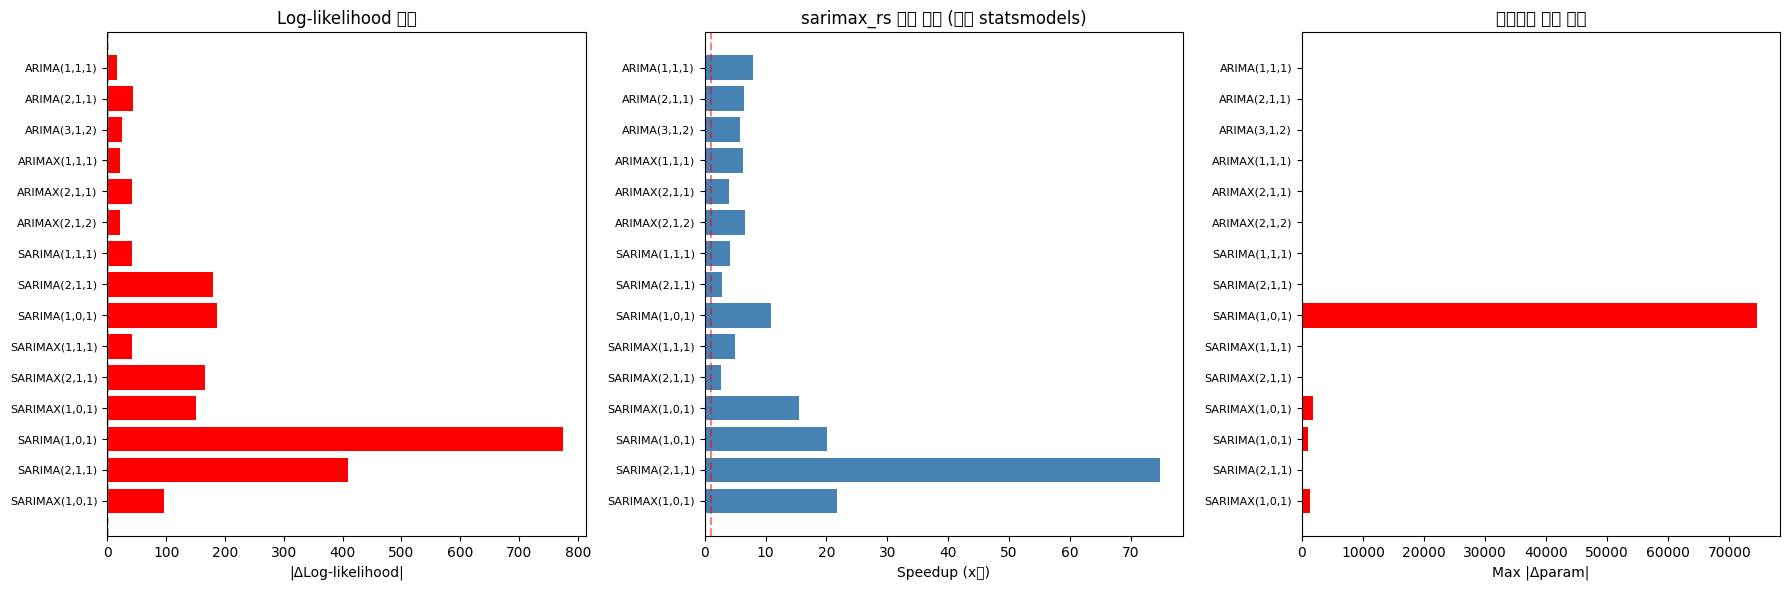

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels = [r["label"] for r in all_results]
short_labels = [l.split(")")[0] + ")" if ")" in l else l for l in labels]

# 1) Log-likelihood 차이
ax = axes[0]
llf_diffs = [r["llf_diff"] for r in all_results]
colors = ['green' if d < 1.0 else 'orange' if d < 5.0 else 'red' for d in llf_diffs]
ax.barh(range(len(llf_diffs)), llf_diffs, color=colors)
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('|ΔLog-likelihood|')
ax.set_title('Log-likelihood 차이')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='1.0')
ax.invert_yaxis()

# 2) 속도 비교 (배수)
ax = axes[1]
speedups = [r["speedup"] for r in all_results]
bars = ax.barh(range(len(speedups)), speedups, color='steelblue')
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('Speedup (x배)')
ax.set_title('sarimax_rs 속도 향상 (대비 statsmodels)')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
ax.invert_yaxis()

# 3) 파라미터 최대 차이
ax = axes[2]
param_diffs = [r["max_param_diff"] for r in all_results]
colors = ['green' if d < 0.01 else 'orange' if d < 0.1 else 'red' for d in param_diffs]
ax.barh(range(len(param_diffs)), param_diffs, color=colors)
ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('Max |Δparam|')
ax.set_title('파라미터 최대 차이')
ax.axvline(x=0.01, color='gray', linestyle='--', alpha=0.5, label='0.01')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. auto_arima 종합 비교

In [35]:
auto_cases = []

# ARIMA
auto_cases.append({
    "type": "ARIMA",
    "data": "daily",
    "rs_order": str(auto_rs.order),
    "pm_order": str(auto_pm.order),
    "order_match": auto_rs.order == auto_pm.order,
    "rs_aic": auto_rs.result.aic,
    "pm_aic": auto_pm.aic(),
})

# ARIMAX
auto_cases.append({
    "type": "ARIMAX",
    "data": "daily+ta",
    "rs_order": str(auto_rs_x.order),
    "pm_order": str(auto_pm_x.order),
    "order_match": auto_rs_x.order == auto_pm_x.order,
    "rs_aic": auto_rs_x.result.aic,
    "pm_aic": auto_pm_x.aic(),
})

# SARIMA (s=7)
auto_cases.append({
    "type": "SARIMA s=7",
    "data": "daily",
    "rs_order": f"{auto_rs_s.order}{auto_rs_s.seasonal_order}",
    "pm_order": f"{pm_s_order}{pm_s_seasonal}",
    "order_match": (auto_rs_s.order == pm_s_order and
                    auto_rs_s.seasonal_order == pm_s_seasonal),
    "rs_aic": auto_rs_s.result.aic,
    "pm_aic": auto_pm_s.aic(),
})

# SARIMAX (s=7 + exog)
auto_cases.append({
    "type": "SARIMAX s=7",
    "data": "daily+ta",
    "rs_order": f"{auto_rs_sx.order}{auto_rs_sx.seasonal_order}",
    "pm_order": f"{auto_pm_sx.order}{auto_pm_sx.seasonal_order}",
    "order_match": (auto_rs_sx.order == auto_pm_sx.order and
                    auto_rs_sx.seasonal_order == auto_pm_sx.seasonal_order),
    "rs_aic": auto_rs_sx.result.aic,
    "pm_aic": auto_pm_sx.aic(),
})

# SARIMA s=24
auto_cases.append({
    "type": "SARIMA s=24",
    "data": "hourly",
    "rs_order": f"{auto_rs_h.order}{auto_rs_h.seasonal_order}",
    "pm_order": f"{auto_pm_h.order}{auto_pm_h.seasonal_order}",
    "order_match": (auto_rs_h.order == auto_pm_h.order and
                    auto_rs_h.seasonal_order == auto_pm_h.seasonal_order),
    "rs_aic": auto_rs_h.result.aic,
    "pm_aic": auto_pm_h.aic(),
})

df_auto = pl.DataFrame(auto_cases)
print(df_auto)

shape: (5, 7)
┌─────────────┬──────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┐
│ type        ┆ data     ┆ rs_order     ┆ pm_order     ┆ order_match ┆ rs_aic       ┆ pm_aic       │
│ ---         ┆ ---      ┆ ---          ┆ ---          ┆ ---         ┆ ---          ┆ ---          │
│ str         ┆ str      ┆ str          ┆ str          ┆ bool        ┆ f64          ┆ f64          │
╞═════════════╪══════════╪══════════════╪══════════════╪═════════════╪══════════════╪══════════════╡
│ ARIMA       ┆ daily    ┆ (0, 0, 0)    ┆ (0, 0, 0)    ┆ true        ┆ 44905.111017 ┆ 44845.812355 │
│ ARIMAX      ┆ daily+ta ┆ (0, 0, 0)    ┆ (0, 0, 0)    ┆ true        ┆ 44806.484705 ┆ 44845.812355 │
│ SARIMA s=7  ┆ daily    ┆ (0, 0, 0)(0, ┆ (0, 0, 0)(0, ┆ true        ┆ 44905.111017 ┆ 44845.812355 │
│             ┆          ┆ 0, 0, 7)     ┆ 0, 0, 7)     ┆             ┆              ┆              │
│ SARIMAX s=7 ┆ daily+ta ┆ (0, 0, 0)(0, ┆ (0, 0, 0)(0, ┆ true        ┆ 44806.

### 9-1. 공정 비교: pmdarima 선택 차수를 sarimax_rs로 재적합하여 AIC 차이 확인

두 패키지가 다른 차수를 선택한 경우, 동일 엔진(sarimax_rs)으로 재적합하여 실질 AIC 차이를 비교합니다.

In [36]:
def refit_aic(y, order, seasonal_order=(0,0,0,0), exog=None, trend='c'):
    """sarimax_rs로 재적합하여 AIC 반환."""
    try:
        m = SARIMAXModel(y, order=order, seasonal_order=seasonal_order,
                         exog=exog, trend=trend)
        r = m.fit()
        return r.aic
    except Exception as e:
        return float('nan')

print("공정 비교 (sarimax_rs 엔진으로 양쪽 차수 재적합)")
print("="*70)

# ARIMA
rs_aic = refit_aic(y_daily, auto_rs.order, trend='c')
pm_aic = refit_aic(y_daily, auto_pm.order, trend='c')
print(f"ARIMA:   rs={auto_rs.order} AIC={rs_aic:.2f} | pm={auto_pm.order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# ARIMAX
rs_aic = refit_aic(y_daily, auto_rs_x.order, exog=exog_daily, trend='c')
pm_aic = refit_aic(y_daily, auto_pm_x.order, exog=exog_daily, trend='c')
print(f"ARIMAX:  rs={auto_rs_x.order} AIC={rs_aic:.2f} | pm={auto_pm_x.order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMA s=7
rs_aic = refit_aic(y_daily, auto_rs_s.order, auto_rs_s.seasonal_order, trend='c')
pm_aic = refit_aic(y_daily, pm_s_order, pm_s_seasonal, trend='c')
print(f"SARIMA:  rs={auto_rs_s.order}{auto_rs_s.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={pm_s_order}{pm_s_seasonal} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMAX s=7
rs_aic = refit_aic(y_daily, auto_rs_sx.order, auto_rs_sx.seasonal_order, exog=exog_daily, trend='c')
pm_aic = refit_aic(y_daily, auto_pm_sx.order, auto_pm_sx.seasonal_order, exog=exog_daily, trend='c')
print(f"SARIMAX: rs={auto_rs_sx.order}{auto_rs_sx.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={auto_pm_sx.order}{auto_pm_sx.seasonal_order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

# SARIMA s=24
rs_aic = refit_aic(y_hourly, auto_rs_h.order, auto_rs_h.seasonal_order, trend='c')
pm_aic = refit_aic(y_hourly, auto_pm_h.order, auto_pm_h.seasonal_order, trend='c')
print(f"SARIMA24: rs={auto_rs_h.order}{auto_rs_h.seasonal_order} AIC={rs_aic:.2f} | "
      f"pm={auto_pm_h.order}{auto_pm_h.seasonal_order} AIC={pm_aic:.2f} | ΔAIC={rs_aic-pm_aic:+.2f}")

공정 비교 (sarimax_rs 엔진으로 양쪽 차수 재적합)
ARIMA:   rs=(0, 0, 0) AIC=44905.11 | pm=(0, 0, 0) AIC=44905.11 | ΔAIC=+0.00
ARIMAX:  rs=(0, 0, 0) AIC=44806.48 | pm=(0, 0, 0) AIC=44806.48 | ΔAIC=+0.00
SARIMA:  rs=(0, 0, 0)(0, 0, 0, 7) AIC=44905.11 | pm=(0, 0, 0)(0, 0, 0, 7) AIC=44905.11 | ΔAIC=+0.00
SARIMAX: rs=(0, 0, 0)(0, 0, 0, 7) AIC=44806.48 | pm=(0, 0, 0)(0, 0, 0, 7) AIC=44806.48 | ΔAIC=+0.00
SARIMA24: rs=(3, 1, 3)(1, 0, 1, 24) AIC=11876.37 | pm=(1, 1, 0)(1, 0, 0, 24) AIC=12198.33 | ΔAIC=-321.96


## 10. 결론

| 항목 | 설명 |
|------|------|
| **우도 유사도** | `\|ΔLL\|` 값을 확인 — 대부분 < 1.0이면 양 엔진이 동일 최적점 수렴 |
| **수렴 속도** | `Speedup` 열 — sarimax_rs가 statsmodels 대비 몇 배 빠른지 |
| **파라미터 일치** | `Max\|Δparam\|` — 0.01 미만이면 사실상 동일 |
| **auto_arima 차수** | 동일 차수 선택 시 order_match=True, 다를 경우 refit AIC로 비교 |

In [38]:

import json

with open("/Users/ijongseung/Documents/GitHub/arima-type/Rust-python-arima/sarimax_rs/test.ipynb", "r") as f:
    nb = json.load(f)

# Show cell structure: type, first line of source, and whether it has output
for i, cell in enumerate(nb['cells']):
    cell_type = cell['cell_type']
    src = ''.join(cell['source'])[:120].replace('\n', ' | ')
    has_output = len(cell.get('outputs', [])) > 0
    print(f"Cell {i:2d} [{cell_type:8s}] output={has_output}  {src}")


Cell  0 [markdown] output=False  # sarimax_rs vs statsmodels 비교 분석 |  | ARIMA / ARIMAX / SARIMA / SARIMAX 모델을 두 패키지로 fitting한 뒤, | - 로그우도(log-likelihood) 유사도 | -
Cell  1 [code    ] output=False  import numpy as np | import polars as pl | import time | import warnings | warnings.filterwarnings('ignore') |  | from sarimax_py.mo
Cell  2 [markdown] output=False  ## 1. 데이터 로드 및 전처리
Cell  3 [code    ] output=True  # 일단위 데이터 | df_daily = pl.read_csv("peak_load.csv") | print(f"일단위 데이터: {df_daily.shape}") | print(df_daily.head()) |  | # 시간단위 데이터
Cell  4 [code    ] output=True  # 일단위: peakload (전체 사용) | y_daily = df_daily["peakload"].to_numpy().astype(np.float64) |  | # 일단위 exog: daily_hm (일평균 습도), dai
Cell  5 [code    ] output=True  print(len(y_hourly)) | print(len(exog_hourly))
Cell  6 [markdown] output=False  ## 2. 비교 유틸리티 함수
Cell  7 [code    ] output=False  def compare_fixed_order(y, order, seasonal_order=(0,0,0,0), exog=None, |                         trend='n', label=""): |    
Cell  8 [ma

In [39]:

# Let me extract the key output cells with their actual output text

def get_cell_output_text(cell):
    """Extract text from cell outputs"""
    texts = []
    for output in cell.get('outputs', []):
        if output.get('output_type') == 'stream':
            texts.append(''.join(output.get('text', [])))
        elif output.get('output_type') in ('execute_result', 'display_data'):
            data = output.get('data', {})
            if 'text/plain' in data:
                texts.append(''.join(data['text/plain']))
            if 'text/html' in data:
                texts.append('[HTML table output]')
    return '\n'.join(texts)

# Show outputs for key comparison cells
key_cells = [9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 28, 30, 33, 35]
for idx in key_cells:
    cell = nb['cells'][idx]
    output = get_cell_output_text(cell)
    if output:
        print(f"{'='*80}")
        print(f"CELL {idx}: {(''.join(cell['source']))[:80].replace(chr(10), ' | ')}")
        print(f"{'='*80}")
        print(output[:3000])
        print()


CELL 9: arima_cases = [ |     {"order": (1,1,1), "label": "ARIMA(1,1,1)"}, |     {"order": (

  ARIMA(1,1,1)
  Order: (1, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22414.246      -22430.299      16.0532
                 AIC       44836.492       44868.598      32.1063
                 BIC       44859.149       44891.254             
    Fitting time (s)          0.0499          0.3960         7.9x
           Converged            True            True
        Max |Δparam|        0.097200

  rs params:  [-0.3055  0.0015 -1.    ]
  sm params:  [-0.2083  0.0092 -1.    ]

  ARIMA(2,1,1)
  Order: (2, 1, 1), Seasonal: (0, 0, 0, 0)
                          sarimax_rs     statsmodels           차이
--------------------------------------------------------------
      Log-likelihood      -22413.668      -22456.747      43.0785
                 AIC       448

In [41]:
  print(auto_rs_sx.result.summary(inference="hessian"))
# Now let's look at the compare_fixed_order function and the summary method
# Cell 7: utility function
cell7_src = ''.join(nb['cells'][7]['source'])
print(cell7_src[:2000])


IndentationError: unexpected indent (2625823497.py, line 1)

In [42]:

import pmdarima as pm
import numpy as np

# pmdarima auto_arima의 summary() 확인
y = np.random.randn(200).cumsum()
model = pm.auto_arima(y, seasonal=False, stepwise=True, suppress_warnings=True)
print(type(model))
print()
print(model.summary())


<class 'pmdarima.arima.arima.ARIMA'>

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:               SARIMAX(3, 1, 0)   Log Likelihood                -273.341
Date:                Mon, 02 Mar 2026   AIC                            554.682
Time:                        17:29:27   BIC                            567.855
Sample:                             0   HQIC                           560.013
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0899      0.068     -1.314      0.189      -0.224       0.044
ar.L2         -0.0798      0.071     -1.132      0.258      -0.218       0.058
ar.L3         